# Day 1 — Data Ingestion & Fund Master Exploration
**Bluestock Fintech | Mutual Fund Analytics Capstone**  
**Task 6:** Understand fund master — print unique fund houses, categories, sub-categories, risk grades


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## 1. Load Fund Master

In [12]:
fm = pd.read_csv("../data/raw/01_fund_master.csv")

print(f"Shape  : {fm.shape}")
print(f"Columns: {fm.columns.tolist()}")
fm.head()


Shape  : (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


## 2. Unique Fund Houses

In [13]:
print(f"Total unique fund houses: {fm['fund_house'].nunique()}")
print()
print(fm['fund_house'].value_counts().to_string())


Total unique fund houses: 10

fund_house
SBI Mutual Fund             5
HDFC Mutual Fund            5
ICICI Prudential MF         5
Nippon India MF             5
Kotak Mahindra MF           4
Axis Mutual Fund            4
Aditya Birla Sun Life MF    3
UTI Mutual Fund             3
Mirae Asset MF              3
DSP Mutual Fund             3


## 3. Categories

In [14]:
print(f"Unique categories: {fm['category'].nunique()}")
print()
print(fm['category'].value_counts().to_string())


Unique categories: 2

category
Equity    34
Debt       6


## 4. Sub-Categories

In [15]:
print(f"Unique sub-categories: {fm['sub_category'].nunique()}")
print()
print(fm['sub_category'].value_counts().to_string())


Unique sub-categories: 12

sub_category
Large Cap          14
Mid Cap             7
Small Cap           6
Liquid              3
Gilt                2
Flexi Cap           2
Short Duration      1
Value               1
Index/ETF           1
Index               1
Large & Mid Cap     1
ELSS                1


## 5. Risk Categories

In [16]:
print(f"Unique risk categories: {fm['risk_category'].nunique()}")
print()
print(fm['risk_category'].value_counts().to_string())


Unique risk categories: 5

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4


## 6. AMFI Scheme Code Structure
AMFI scheme codes are unique 6-digit numeric IDs assigned sequentially at registration.  
Each scheme variant (Direct/Regular × Growth/IDCW) gets its own separate code.


In [17]:
print(f"AMFI Code range : {fm['amfi_code'].min()} → {fm['amfi_code'].max()}")
print(f"Plans available : {fm['plan'].unique()}")
print(f"Total schemes   : {len(fm)}")
print()

# Show one fund house with both Direct and Regular plans
sample = fm[fm['fund_house'] == fm['fund_house'].iloc[0]][['amfi_code','scheme_name','plan','sub_category']]
print("Sample — Direct vs Regular plans for same fund house:")
print(sample.to_string(index=False))


AMFI Code range : 100016 → 149324
Plans available : <ArrowStringArray>
['Regular', 'Direct']
Length: 2, dtype: str
Total schemes   : 40

Sample — Direct vs Regular plans for same fund house:
 amfi_code                                  scheme_name    plan sub_category
    119551    SBI Bluechip Fund - Regular Plan - Growth Regular    Large Cap
    119552     SBI Bluechip Fund - Direct Plan - Growth  Direct    Large Cap
    119598   SBI Small Cap Fund - Regular Plan - Growth Regular    Small Cap
    119599    SBI Small Cap Fund - Direct Plan - Growth  Direct    Small Cap
    119120 SBI Magnum Gilt Fund - Regular Plan - Growth Regular         Gilt


## 7. Visual Summary

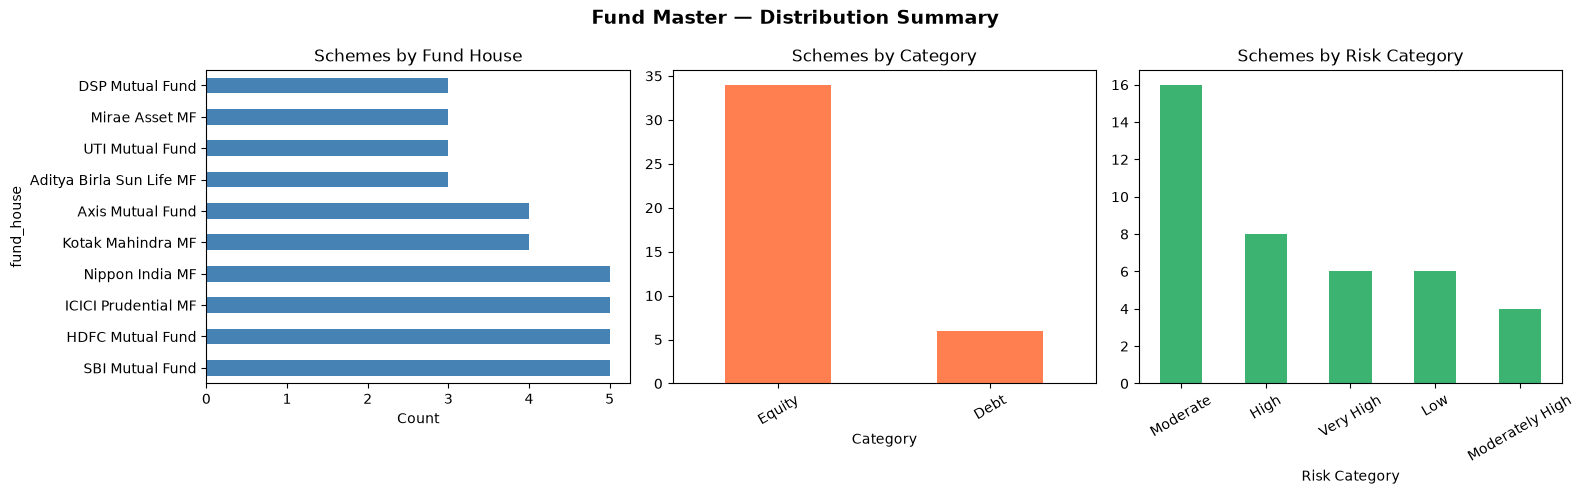

Chart saved → reports/fund_master_distribution.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fund Master — Distribution Summary", fontsize=14, fontweight='bold')

# Fund house distribution
fm['fund_house'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Schemes by Fund House")
axes[0].set_xlabel("Count")

# Category distribution
fm['category'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Schemes by Category")
axes[1].set_xlabel("Category")
axes[1].tick_params(axis='x', rotation=30)

# Risk category distribution
fm['risk_category'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title("Schemes by Risk Category")
axes[2].set_xlabel("Risk Category")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../reports/fund_master_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved → reports/fund_master_distribution.png")


## 8. Key Findings

- **Fund Houses:** Note which AMC has the most schemes in the dataset
- **Categories:** Equity dominates, followed by Debt and Hybrid
- **Sub-categories:** Large Cap, Mid Cap, Small Cap are the key equity buckets
- **Risk:** Most equity funds fall under High / Very High risk as per SEBI norms
- **AMFI Codes:** Direct plans have higher code numbers than their Regular counterparts (registered later)
